In [149]:
import torch
from sklearn.preprocessing import StandardScaler
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import random 
from pathlib import Path
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.path.dirname('utils.py'), ".."))
sys.path.append(parent_dir)
import utils as ut

In [150]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
BATCH_SIZE = 32
EPOCHS = 5000
LR = 1e-4
WD = 1e-2
WEIGHTS = torch.tensor([1.0, 2.0]).to(DEVICE)
RUN = True # Determines if notebook trains model

params = {'num_outputs': 2,
          'dropout': 0.6,
          'scale': 32}

DEVICE # check device

device(type='cpu')

In [151]:
random.seed(SEED)
torch.manual_seed(SEED)

In [152]:
logged_params = params.copy()
if RUN:
    logged_params['comment'] = input("Enter a comment for this training run: ")
    logged_params['seed'] = SEED
    logged_params['batch size'] = BATCH_SIZE
    logged_params['epochs'] = EPOCHS
    logged_params['learning rate'] = LR
    logged_params['weight decay'] = WD

In [153]:
cwd = Path.cwd()
cutout_dir = cwd.parent / 'data' / 'cutouts'
table_dir = cwd.parent / 'data' / 'tables'
model_dir = cwd.parent / 'models'

In [154]:
# combine flux columns

tables = table_dir.rglob('*')
df = pd.concat((pd.read_csv(t) for t in tables), ignore_index=True)

ceers_flux = df.filter(regex='^FLUX_')
ceers_err = df.filter(regex='^FLUXERR_')
primer_flux = df.filter(regex='^f_f') / 10
primer_err = df.filter(regex='^e_f') / 10

df.drop((list(ceers_flux.columns) + list(primer_flux.columns)
         + list(ceers_err.columns) + list(primer_err.columns)),
         inplace=True, axis=1)

ceers_flux.rename(columns=lambda x: x.replace('FLUX_', 'F'), inplace=True)
primer_flux.rename(columns=lambda x: x.replace('f_f', 'F')[:-1], inplace=True)
ceers_err.rename(columns=lambda x: x.replace('FLUXERR_', 'E'), inplace=True)
primer_err.rename(columns=lambda x: x.replace('e_f', 'E')[:-1], inplace=True)

combined_flux = ceers_flux.combine_first(primer_flux)
combined_err = ceers_err.combine_first(primer_err)

combined_flux = combined_flux.mask(combined_flux <= 0.1, np.nan)
combined_err = combined_err.mask(combined_err <= 0.1, np.nan)

df = pd.concat([df, np.log10(combined_flux), np.log10(combined_err)], axis=1)

In [155]:
in_features = ['beta', 'Av'] + ['F115', 'F150', 'F277', 'F444']
out_features = ['flag']

logged_params['input features'] = in_features
logged_params['output features'] = out_features

df = df[in_features + out_features]
df.dropna(inplace=True)

bad_av = df['Av'] == -99
bad_beta = df['beta'] == -99
df = df[~bad_beta | ~bad_av]

mask = (df['flag'] == 1.0)
dfs = {'dusty': df[mask],
       'nodust': df[~mask]}

print(len(dfs['dusty']) + len(dfs['nodust']))
dfs['dusty'].head()

449


,beta,Av,F115,F150,F277,F444,flag
0,0.0867,1.131232,2.468827,3.052597,3.412483,3.782708,1
4,0.2730,1.337985,2.991077,3.532909,4.094634,4.351010,1
7,0.3220,0.963417,3.076358,3.453188,3.739712,3.959615,1
8,1.4900,2.006854,2.180589,2.709070,3.597237,4.037870,1
16,1.2100,1.368635,2.567169,2.987262,3.500033,3.834898,1


In [156]:
train_df = pd.DataFrame()
val_df = pd.DataFrame()
for key in dfs:
    df = dfs[key]
    n_val = int(len(df) * 0.2)

    train_df = pd.concat([df.iloc[n_val:], train_df], ignore_index=True)
    val_df = pd.concat([df.iloc[:n_val], val_df], ignore_index=True)

train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

scaler = StandardScaler()
train_df[in_features] = scaler.fit_transform(train_df[in_features])
val_df[in_features] = scaler.transform(val_df[in_features])

size = len(train_df) + len(val_df)
logged_params['sample size'] = size

size

449

In [157]:
X_train = torch.tensor(train_df[in_features].values)
X_val = torch.tensor(val_df[in_features].values)
y_train = torch.tensor(train_df['flag'].values)
y_val = torch.tensor(val_df['flag'].values)

In [158]:
class FCBlock(nn.Module):
    def __init__(self, input_dim, dropout, num_outputs, scale=32):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(input_dim, input_dim*scale),
            nn.BatchNorm1d(input_dim*scale),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(input_dim*scale, input_dim*scale//2),
            nn.BatchNorm1d(input_dim*scale//2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(input_dim*scale//2, input_dim*scale//4),
            nn.BatchNorm1d(input_dim*scale//4),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),


            nn.Linear(input_dim*scale//4, num_outputs))

    def forward(self, x):
        return self.block(x)

In [159]:
class GalaxyClassifier(nn.Module):
    "Full Galaxy Classifier network."
    def __init__(
        self,
        num_outputs: int = 1,
        input_dim: int = 8,
        scale: int = 4,
        dropout: float = 0.4,
        **kwargs):

        super().__init__()
        self.fc = FCBlock(
            input_dim=input_dim, 
            dropout=dropout, 
            num_outputs=num_outputs, 
            scale=scale)

    def forward(self, x):
        x = self.fc(x)

        return x

In [160]:
params['input_dim'] = len(in_features)
params

{'num_outputs': 2, 'dropout': 0.6, 'scale': 32, 'input_dim': 6}

In [161]:
loss_func = torch.nn.CrossEntropyLoss(weight=WEIGHTS)
model = GalaxyClassifier(**params).to(DEVICE) 
optimizer = torch.optim.AdamW(model.parameters(), lr = LR, weight_decay=WD)

logged_params['loss function'] = str(loss_func)
logged_params['model'] = str(model)
logged_params['optimizer'] = str(optimizer)

model_path = None
if model_path is not None:
        checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

        # 3. Restore the states
        model.load_state_dict(checkpoint['model_state_dict'])

        # 4. Restore metadata variables
        start_epoch = checkpoint['epoch']
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
else:
        start_epoch = 1
        train_losses = []
        val_losses = []

In [162]:
# 'dummy' data points to test if model takes and gives inputs / outputs
# of correct shape without crashing
dummy = torch.randn(8, len(in_features)).to(DEVICE)
out = model(dummy)
print(f"Output shape: {out.shape}")

# calculate number of model parameters
num_params = sum(p.numel() for p in model.parameters())
logged_params['num params'] = num_params

print(f"Params: {num_params:,}") 

Output shape: torch.Size([8, 2])
Params: 25,298


In [163]:
# sets the number of galaxies used in training
train_size = len(X_train)
val_size = len(X_val)

# set up minibatches
train_data = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_data,
                                           batch_size=BATCH_SIZE,
                                           shuffle=True)

val_data = torch.utils.data.TensorDataset(X_val, y_val)
val_loader = torch.utils.data.DataLoader(val_data,
                                           batch_size=BATCH_SIZE,
                                           shuffle=True)

In [164]:
from tqdm.auto import trange

if RUN:
    train_losses = []
    val_losses = []
    
    # Training Loop ---------------------------------------------------------------------------------------
    for epoch in trange(EPOCHS, desc="Epochs", smoothing=0):
        model.train()
        running_loss = 0
        num_done = 0

        for data, labels in train_loader:
            optimizer.zero_grad()
            if data.ndim == 1:
                data = data.unsqueeze(1)
            data = data.float()
            outputs = model(data)
            labels = labels.long() # FOR CLASSIFICATION 
            loss = loss_func(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            num_done += data.size(0)
            running_avg_loss = (running_loss / num_done) ** 0.5

        train_losses.append(running_avg_loss) # track loss only once per epoch
        #scheduler.step()

        # Compute Validation Accuracy ----------------------------------------------------------------------
        model.eval()
        running_loss = 0
        num_done = 0

        with torch.no_grad():
            for data, labels in val_loader:
                if data.ndim == 1:
                    data = data.unsqueeze(1)
                data = data.float()
                
                outputs = model(data)
                labels = labels.long()
                loss = loss_func(outputs, labels)

                running_loss += loss.item() * data.size(0)
                num_done += data.size(0)

                running_avg_val_loss = (running_loss / num_done) ** 0.5
                
            val_losses.append(running_avg_val_loss)

Epochs:   0%|          | 0/5000 [00:00<?, ?it/s]

In [165]:
if RUN: 
    model.eval()

    corr = 0
    tot = 0

    preds = []
    lbls = []

    with torch.no_grad():
        for data, labels in val_loader:
            labels = labels.long()
            if data.ndim == 1:
                data = data.unsqueeze(1)
            data = data.float()
            outputs = model(data)

            tot += data.size(0)
            predictions = torch.argmax(outputs, dim=1)
            corr += (predictions == labels).float().sum()

            preds.extend(predictions.tolist())
            lbls.extend(labels.tolist())
            
    resdf = pd.DataFrame()
    resdf['labels'] = lbls
    resdf['predictions'] = preds
    resdf['correct'] = (resdf['labels'] == resdf['predictions'])

    confusion_matrix = pd.crosstab(resdf['labels'], resdf['predictions'], 
                                   rownames=['Actual'], colnames=['Predicted'])

    # index with actual, predicted
    try:
        false_pos = confusion_matrix.loc[0, 1]
        false_neg = confusion_matrix.loc[1, 0]
        true_pos = confusion_matrix.loc[1, 1]
        true_neg = confusion_matrix.loc[0, 0]

        purity = true_pos / (true_pos + false_pos)
        completeness = true_pos / (true_pos + false_neg)

        logged_params['purity (dusty)'] = purity
        logged_params['completeness (dusty)'] = completeness        
    except:
        pass

    accuracy = float((corr / tot))

    logged_params['accuracy'] = accuracy
    logged_params['confusion matrix'] = str(confusion_matrix)
    logged_params['last validation loss'] = val_losses[-1]

In [166]:
if RUN:
    name = f"model_{val_losses[-1]:.3f}.pth"
    # save the model along with loss curve data so I can test different parameters and keep the best one
    torch.save({'epoch': EPOCHS + start_epoch,
                'model_state_dict': model.state_dict(),
                'train_losses': train_losses,
                'optimizer_state_dict': optimizer.state_dict(),
                'val_losses': val_losses},
                model_dir / 'fc' / f"model_{val_losses[-1]:.3f}.pth")
    
    # also log the run
    logger = ut.RunLogger(filepath=cwd.parent / 'logs' / 'fc_log.json')
    logger.log_run(logged_params)

purity:  0.6428571428571429 completeness:  0.5806451612903226
accuracy:  0.7415730357170105


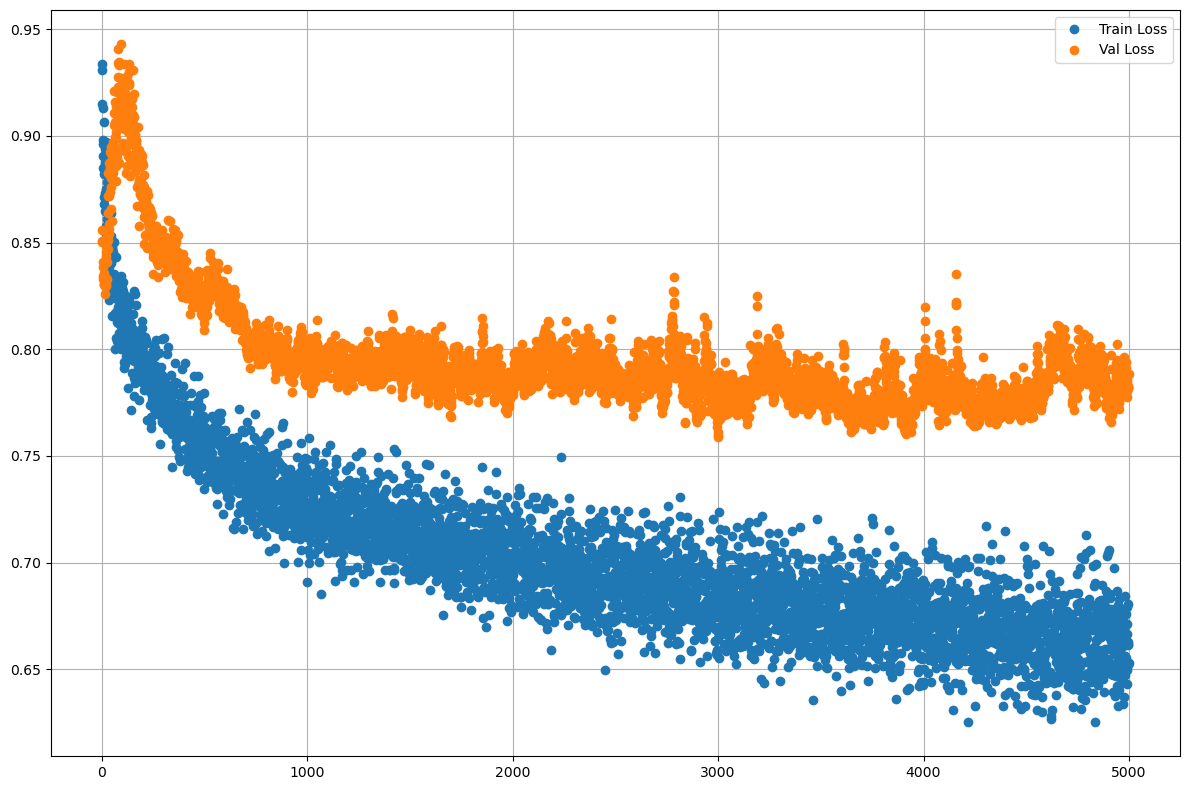

In [170]:
if RUN:
    fig, ax = plt.subplots(figsize=(12,8))
    ax.plot(train_losses, label="Train Loss", marker='o', linestyle='None')
    ax.plot(val_losses, label="Val Loss", marker='o',linestyle='None')
    ax.grid()
    ax.legend()
    fig.tight_layout()

    try:
        print('purity: ', purity, 'completeness: ', completeness)
    except:
        pass
    print('accuracy: ', accuracy)

In [168]:
eval = False

if eval:
    model_path = r"C:\Users\harty\Code\Galaxy-Classifier\Summer Research\models\regression\model_3.363.pth" # new model path 

    params = {'in_channels': 3,
            'num_outputs': 1,
            'conv_channels': 8,
            'embed_dim': 32,
            'num_heads': 2,
            'num_cvt_layers': 1,
            'fc_dim': 32,
            'dropout': 0.4}

    model = GalaxyClassifier(**params).to(DEVICE) # untrained model with same dimensions as the one in model_path

    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

    # get losses and model from file
    model.load_state_dict(checkpoint['model_state_dict'])
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']

    model.eval()

    corr = 0
    tot = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model(imgs)
            print(outputs.std(), outputs.max())

            tot += imgs.size(0)
            corr += sum(1 for x, y in zip(labels, outputs) if x >= 15 and y >= 15)
            corr += sum(1 for x, y in zip(labels, outputs) if x < 15 and y < 15)
            
    corr / tot